In [ ]:
from google.colab import files
files.upload()


Saving battery_clean_B0005.csv to battery_clean_B0005.csv


{'battery_clean_B0005.csv': b'voltage,current,temperature,capacity,health\n3.5298286688693397,-1.8187019641679727,32.572328114029,1.8564874208181574,100.0\n3.5373201277859714,-1.8175598506612867,32.72523522519307,1.846327249719927,99.45272071416714\n3.5437367282719,-1.8164865418840956,32.64286193755933,1.8353491942234077,98.86138595081705\n3.5436661072601456,-1.8255891938692528,32.51487646204882,1.8352625275821128,98.85671763794173\n3.5423432526672167,-1.8261139590277586,32.38234901543077,1.8346455082120419,98.82348178817772\n3.5413347346347575,-1.8168108743168803,32.43418218230641,1.8356616600675495,98.87821697485944\n3.5410250495075215,-1.816791144707133,32.480416444757985,1.8351461429226603,98.85044855913476\n3.554133296801584,-1.8443412120754061,32.41046186109587,1.8257567905665537,98.34468955151549\n3.5529355991467955,-1.853972745505648,32.3461408313,1.8247738529891333,98.29174345738105\n3.5512057319376997,-1.8535899338510957,32.27679750791685,1.824613268496936,98.2830935473199\n3

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [ ]:
df = pd.read_csv("battery_clean_B0005.csv")

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   voltage      168 non-null    float64
 1   current      168 non-null    float64
 2   temperature  168 non-null    float64
 3   capacity     168 non-null    float64
 4   health       168 non-null    float64
dtypes: float64(5)
memory usage: 6.7 KB


In [ ]:
df = pd.read_csv("battery_clean_B0005.csv")


df.insert(0, "cycle", range(1, len(df) + 1))

df.head()


,cycle,voltage,current,temperature,capacity,health
0,1,3.529829,-1.818702,32.572328,1.856487,100.000000
1,2,3.537320,-1.817560,32.725235,1.846327,99.452721
2,3,3.543737,-1.816487,32.642862,1.835349,98.861386
3,4,3.543666,-1.825589,32.514876,1.835263,98.856718
4,5,3.542343,-1.826114,32.382349,1.834646,98.823482


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cycle        168 non-null    int64  
 1   voltage      168 non-null    float64
 2   current      168 non-null    float64
 3   temperature  168 non-null    float64
 4   capacity     168 non-null    float64
 5   health       168 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 8.0 KB


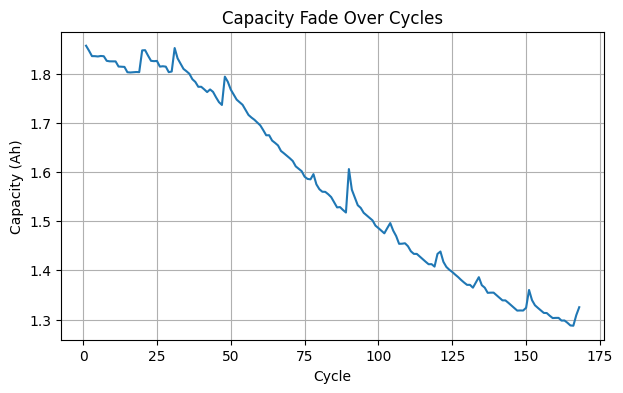

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(df["cycle"], df["capacity"])
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Fade Over Cycles")
plt.grid()
plt.show()


In [ ]:
X = df[["voltage", "current", "temperature", "cycle"]]
y = df["health"]


In [ ]:
import pandas as pd

df = pd.read_csv("/content/battery_clean_B0005.csv")

# Re-add cycle if notebook was reset
if "cycle" not in df.columns:
    df.insert(0, "cycle", range(1, len(df) + 1))

df.tail()


,cycle,voltage,current,temperature,capacity,health
163,164,3.466462,-1.674488,33.275688,1.293464,69.672630
164,165,3.468509,-1.667447,33.320678,1.288003,69.378514
165,166,3.466806,-1.667470,33.373150,1.287453,69.348842
166,167,3.471071,-1.688898,33.713519,1.309015,70.510328
167,168,3.475472,-1.697928,33.865318,1.325079,71.375616


In [ ]:
df["log_cycle"] = np.log1p(df["cycle"])


In [ ]:
X = df[["voltage", "current", "temperature", "log_cycle"]]
y = df["health"]


In [ ]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1

mask = (y >= Q1 - 1.5*IQR) & (y <= Q3 + 1.5*IQR)

X = X[mask]
y = y[mask]

print("Samples after filtering:", len(X))


Samples after filtering: 168


In [ ]:
base_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

scores = cross_val_score(
    base_model,
    X, y,
    scoring="neg_mean_absolute_error",
    cv=5
)

print("Baseline CV MAE:", -scores.mean())


Baseline CV MAE: 2.2106218331364853


In [ ]:
param_grid = {
    "n_estimators": [300, 500, 700],
    "max_depth": [6, 10, None],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", 0.7]
}


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
rf = RandomForestRegressor(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X, y)


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [6, 10, None],
                         'max_features': ['sqrt', 0.7],
                         'min_samples_leaf': [1, 3, 5],
                         'n_estimators': [300, 500, 700]},
             scoring='neg_mean_absolute_error')

In [ ]:
print("BEST CV MAE:", -grid.best_score_)
print("BEST PARAMETERS:", grid.best_params_)

best_model = grid.best_estimator_


BEST CV MAE: 2.599906470993797
BEST PARAMETERS: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("FINAL TEST MAE:", mean_absolute_error(y_test, y_pred))


FINAL TEST MAE: 0.4606241221663004


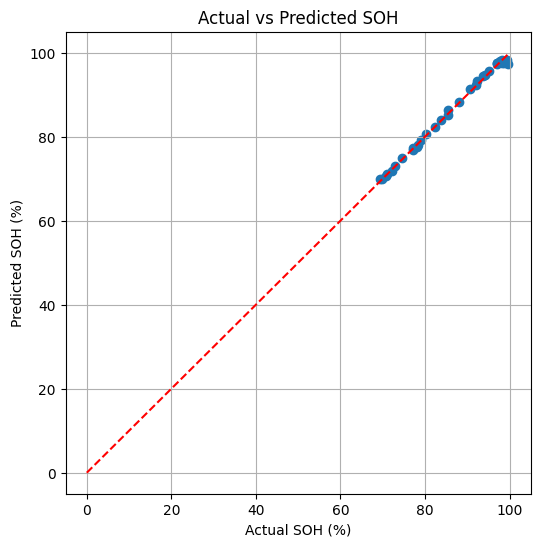

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([0,100], [0,100], 'r--')
plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Actual vs Predicted SOH")
plt.grid()
plt.show()


In [ ]:
def detect_fault(row):
    faults = []

    if row["voltage"] < 3.0 or row["voltage"] > 4.25:
        faults.append("Voltage Fault")

    if row["current"] > 2.0:
        faults.append("Overcurrent Fault")

    if row["temperature"] > 50:
        faults.append("Overtemperature Fault")

    if row["health"] < 50:
        faults.append("Low SOH Fault")

    if len(faults) == 0:
        return "Normal"
    else:
        return ", ".join(faults)


In [ ]:
df["fault_status"] = df.apply(detect_fault, axis=1)
df[["voltage", "current", "temperature", "health", "fault_status"]].head(10)


,voltage,current,temperature,health,fault_status
0,3.529829,-1.818702,32.572328,100.000000,Normal
1,3.537320,-1.817560,32.725235,99.452721,Normal
2,3.543737,-1.816487,32.642862,98.861386,Normal
3,3.543666,-1.825589,32.514876,98.856718,Normal
4,3.542343,-1.826114,32.382349,98.823482,Normal
5,3.541335,-1.816811,32.434182,98.878217,Normal
6,3.541025,-1.816791,32.480416,98.850449,Normal
7,3.554133,-1.844341,32.410462,98.344690,Normal
8,3.552936,-1.853973,32.346141,98.291743,Normal
9,3.551206,-1.853590,32.276798,98.283094,Normal


In [ ]:
df["fault_status"].value_counts()


,count
fault_status,
Normal,168


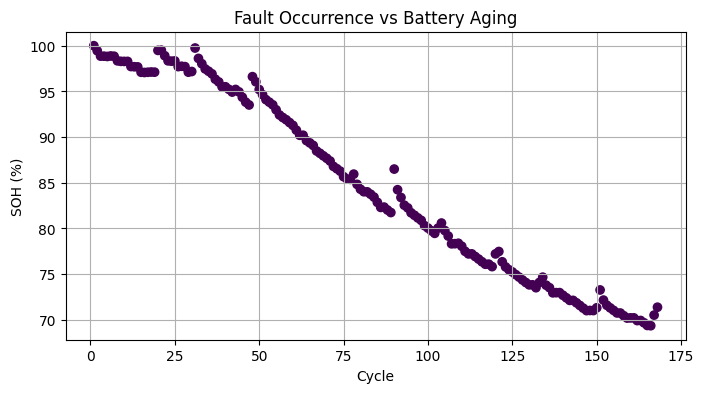

In [ ]:
fault_flag = df["fault_status"] != "Normal"

import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["cycle"], df["health"], c=fault_flag)
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("Fault Occurrence vs Battery Aging")
plt.grid()
plt.show()


In [ ]:
sample = {
    "voltage": 4.3,
    "current": 2.4,
    "temperature": 55,
    "health": 42
}

sample_df = pd.DataFrame([sample])
sample_df["fault_status"] = sample_df.apply(detect_fault, axis=1)

sample_df


,voltage,current,temperature,health,fault_status
0,4.3,2.4,55,42,"Voltage Fault, Overcurrent Fault, Overtemperat..."


In [ ]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


In [ ]:
df = pd.read_csv("battery_clean_B0005.csv")

# add cycle
if "cycle" not in df.columns:
    df.insert(0, "cycle", range(1, len(df) + 1))

# log cycle
df["log_cycle"] = np.log1p(df["cycle"])

df.head()


,cycle,voltage,current,temperature,capacity,health,log_cycle
0,1,3.529829,-1.818702,32.572328,1.856487,100.000000,0.693147
1,2,3.537320,-1.817560,32.725235,1.846327,99.452721,1.098612
2,3,3.543737,-1.816487,32.642862,1.835349,98.861386,1.386294
3,4,3.543666,-1.825589,32.514876,1.835263,98.856718,1.609438
4,5,3.542343,-1.826114,32.382349,1.834646,98.823482,1.791759


In [ ]:
features = ["voltage", "current", "temperature", "log_cycle"]
X = df[features]
y_health = df["health"]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']

In [ ]:
health_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

health_model.fit(X_scaled, y_health)

joblib.dump(health_model, "health_regression_model.pkl")


['health_regression_model.pkl']

In [ ]:
def label_health(h):
    if h > 80:
        return 0
    elif h > 50:
        return 1
    else:
        return 2

y_condition = y_health.apply(label_health)

condition_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

condition_model.fit(X_scaled, y_condition)

joblib.dump(condition_model, "condition_classifier_model.pkl")


['condition_classifier_model.pkl']

In [ ]:
fault_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

fault_model.fit(X_scaled)

joblib.dump(fault_model, "fault_isolation_forest.pkl")


['fault_isolation_forest.pkl']

In [ ]:
pca = PCA(n_components=2)
pca.fit(X_scaled)

joblib.dump(pca, "pca_model.pkl")


['pca_model.pkl']

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(pca.transform(X_scaled))

joblib.dump(kmeans, "kmeans_model.pkl")


['kmeans_model.pkl']

In [ ]:
!ls -lh *.pkl


-rw-r--r-- 1 root root 224K Feb  1 15:01 condition_classifier_model.pkl
-rw-r--r-- 1 root root 1.3M Feb  1 15:01 fault_isolation_forest.pkl
-rw-r--r-- 1 root root 7.5M Feb  1 15:01 health_regression_model.pkl
-rw-r--r-- 1 root root 1.5K Feb  1 15:01 kmeans_model.pkl
-rw-r--r-- 1 root root 1.1K Feb  1 15:01 pca_model.pkl
-rw-r--r-- 1 root root 1015 Feb  1 15:01 scaler.pkl


In [ ]:
!zip battery_ml_models.zip *.pkl


  adding: condition_classifier_model.pkl (deflated 92%)
  adding: fault_isolation_forest.pkl (deflated 76%)
  adding: health_regression_model.pkl (deflated 78%)
  adding: kmeans_model.pkl (deflated 58%)
  adding: pca_model.pkl (deflated 33%)
  adding: scaler.pkl (deflated 38%)


In [ ]:
from google.colab import files
files.download("battery_ml_models.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>